# Unsupervied Learning (Clustering)

In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris



In [8]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)


In [9]:
df.shape

(150, 4)

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

print(inertia)

[681.3706, 152.3479517603579, 78.8556658259773, 57.35088021295475, 46.472230158730156, 39.066035353535355, 34.3058152958153, 30.476222943722945, 29.906246659137967, 28.54529781003311]


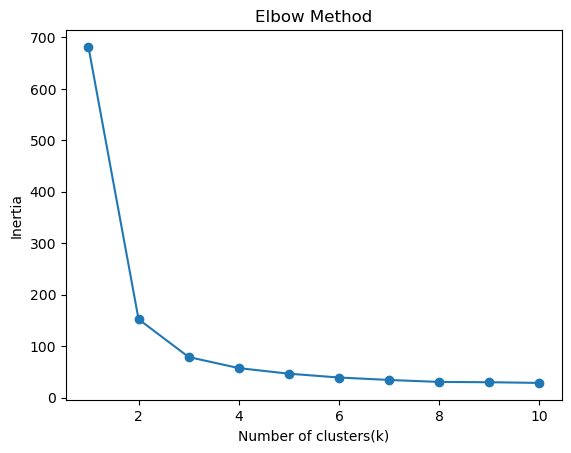

In [19]:
plt.plot(range(1,11), inertia, marker = 'o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title('Elbow Method')
plt.show()

In [22]:
kmeans = KMeans(n_clusters = 3, random_state=42)

In [23]:
kmeans.fit(df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [24]:
df['cluster'] = kmeans.labels_

In [26]:
df.head(20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


In [27]:
df['cluster'].value_counts()

cluster
2    61
1    50
0    39
Name: count, dtype: int64

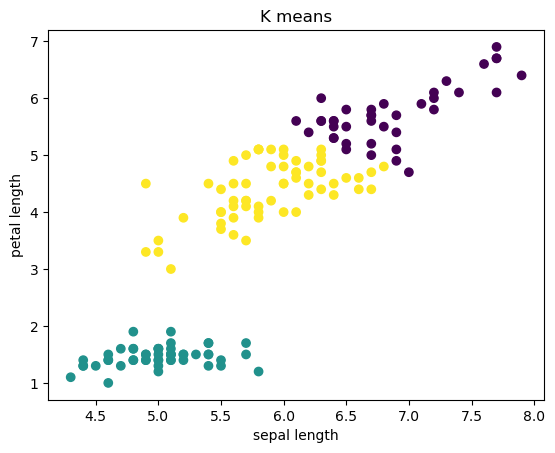

In [29]:
plt.scatter(df.iloc[:,0], df.iloc[:,2], c=df['cluster'], cmap='viridis')
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.title('K means')
plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler


In [38]:
df_new = pd.read_excel('Mall Customers.xlsx')

In [39]:
df_new.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [43]:
print(df_new.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']


In [50]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [45]:
x = df_new[["Annual Income (k$)", "Spending Score (1-100)"]]

In [48]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [49]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

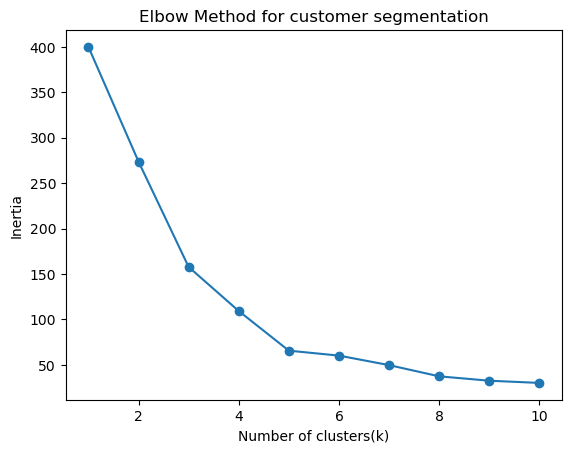

In [52]:
plt.plot(range(1,11), inertia, marker = 'o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title('Elbow Method for customer segmentation')
plt.show()

In [54]:
kmeans = KMeans(n_clusters = 5, random_state=42)
df_new['Cluster'] = kmeans.fit_predict(x_scaled)

In [55]:
df_new

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,M,19,High School,Married,15,39,4
1,2,M,21,Graduate,Single,15,81,2
2,3,F,20,Graduate,Married,16,6,4
3,4,F,23,High School,Unknown,16,77,2
4,5,F,31,Uneducated,Married,17,40,4
...,...,...,...,...,...,...,...,...
195,196,F,35,High School,Married,120,79,1
196,197,F,45,High School,Unknown,126,28,3
197,198,M,32,Uneducated,Married,126,74,1
198,199,M,32,High School,Married,137,18,3


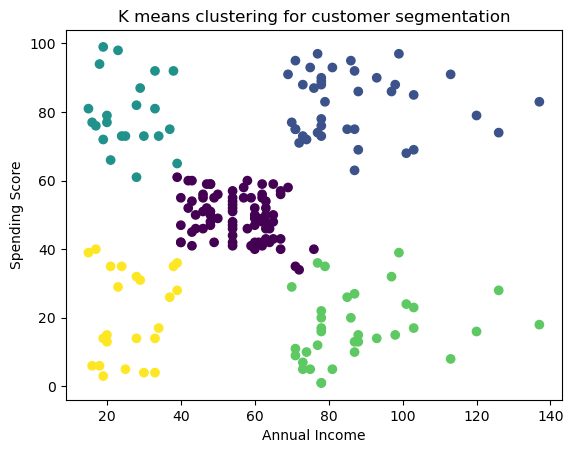

In [63]:
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=df_new['Cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K means clustering for customer segmentation')
plt.show()

In [59]:
cluster_summary = df_new.groupby('Cluster')[['Annual Income (k$)', "Spending Score (1-100)"]].mean()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


0: Average Earners, Average Spenders  
1: High Earners, High Spenders  
2: Low Earners, High Spenders  
3: High Earners, Low Spenders  
4: Low Earners, Low Spenders  

In [64]:
# number of people in each cluster 
df_new['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [67]:
cluster_names = {
    0:"Average Shoppers",
    1:"Premium Shoppers",
    2:"Impulsive Shoppers",
    3:"Careful Shoppers",
    4:"Budget Shoppers"
}

df_new["Shopper Type"] = df_new['Cluster'].map(cluster_names)

In [68]:
df_new.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster,Label,Shopper Type
0,1,M,19,High School,Married,15,39,4,Budget Shoppers,Budget Shoppers
1,2,M,21,Graduate,Single,15,81,2,Impulsive Shoppers,Impulsive Shoppers
2,3,F,20,Graduate,Married,16,6,4,Budget Shoppers,Budget Shoppers
3,4,F,23,High School,Unknown,16,77,2,Impulsive Shoppers,Impulsive Shoppers
4,5,F,31,Uneducated,Married,17,40,4,Budget Shoppers,Budget Shoppers


In [69]:
df_new['Shopper Type'].value_counts()

Shopper Type
Average Shoppers      81
Premium Shoppers      39
Careful Shoppers      35
Budget Shoppers       23
Impulsive Shoppers    22
Name: count, dtype: int64

In [70]:
centroid = kmeans.cluster_centers_

In [71]:
print(centroid)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [73]:
# inverse transform to get actual values 
centroid_original = scaler.inverse_transform(centroid)
centroid_df = pd.DataFrame(centroid_original,columns=['Annual Income (k$)', "Spending Score (1-100)"])
print(centroid_df)

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


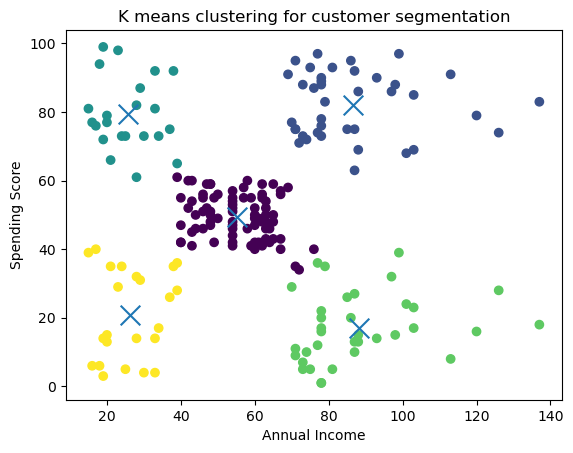

In [74]:
plt.scatter(x['Annual Income (k$)'], x["Spending Score (1-100)"], c=kmeans.labels_, cmap='viridis')
plt.scatter(centroid_original[:,0], centroid_original[:,1], marker='x',s=200)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K means clustering for customer segmentation')
plt.show()

silhoutte computes the distances between the datapoints and the centroid and 
the neighbouring clusters to tell how distinct the clusters are 

In [79]:
from sklearn.metrics import silhouette_score

In [81]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, silhouette Score = {score:.3f}")

k = 2, silhouette Score = 0.397
k = 3, silhouette Score = 0.467
k = 4, silhouette Score = 0.494
k = 5, silhouette Score = 0.555
k = 6, silhouette Score = 0.514
k = 7, silhouette Score = 0.502
k = 8, silhouette Score = 0.455
k = 9, silhouette Score = 0.457
k = 10, silhouette Score = 0.445


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.

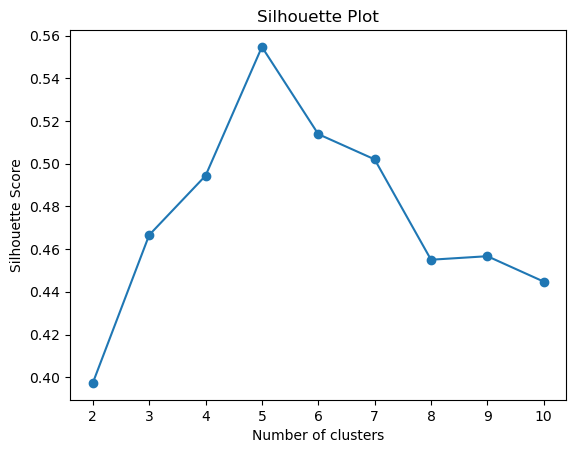

In [82]:
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Plot')
plt.show()